# Vision Model BPP vs Accuracy Plot

결과 디렉토리를 스캔해 bpp-accuracy 곡선을 그립니다.  
- `lmbda*_imagenet_result.json` 파일에서 bpp와 top1을 읽음  
- lambda 키 기준으로 시드 간 평균/SE를 계산  
- 스타일은 `plot_bpp_acc_v5_csv` 와 동일

In [31]:
import json
import re
import os
import glob
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.ticker as ticker
from collections import defaultdict
from scipy.interpolate import make_interp_spline


In [32]:
# ───────────────────────────────────────────────────────────────
# Data collection
# ───────────────────────────────────────────────────────────────

def extract_lambda(filename):
    """파일명에서 lambda 값 추출.  lmbda<N>_imagenet_result.json"""    
    m = re.search(r'lmbda(\d+(?:\.\d+)?)', filename)
    return float(m.group(1)) if m else None


def read_imagenet_result(path):
    """JSON 결과 파일에서 (bpp, top1, top5) 반환."""    
    with open(path) as f:
        d = json.load(f)
    bpp = d.get('bpp_loss', d.get('bpp', None))
    if 'ppl' in d and 'imagenet' in d['ppl']:
        top1, top5 = d['ppl']['imagenet'][0], d['ppl']['imagenet'][1]
    elif 'iamagenet' in d:
        top1, top5 = d['iamagenet'][0], d['iamagenet'][1]
    else:
        top1, top5 = None, None
    return bpp, top1, top5


def collect_experiment(exp_dir, metric_scale=100.0):
    """
    exp_dir 내의 모든 lmbda*_imagenet_result.json을 읽어
    {lambda: {'bpp': float, 'top1': float, 'top5': float}} 반환.
    metric_scale: CLIP/SigLIP는 0~1 → 100 배수, DINOv2는 그대로(1.0).
    """
    result = {}
    for path in glob.glob(os.path.join(exp_dir, 'lmbda*_imagenet_result.json')):
        lmb = extract_lambda(os.path.basename(path))
        if lmb is None:
            continue
        bpp, top1, top5 = read_imagenet_result(path)
        if bpp is None or top1 is None:
            continue
        if bpp <= 0:
            continue
        result[lmb] = {
            'bpp': bpp,
            'top1': top1 * metric_scale,
            'top5': top5 * metric_scale if top5 is not None else None,
        }
    return result


def load_base_accuracy(model_dir, metric_scale=100.0):
    """base_imagenet_result.json 에서 baseline top1 반환."""    
    path = os.path.join(model_dir, 'base_imagenet_result.json')
    if not os.path.exists(path):
        return None
    _, top1, _ = read_imagenet_result(path)
    return top1 * metric_scale if top1 is not None else None


def collect_bit_experiment(result_dir_pattern, bits, metric_scale=100.0):
    """
    QTIP 같이 bit 단위 파일 구조 지원:
    result_dir_pattern.format(b=bit) 형태.
    {bit: {'bpp': float, 'top1': float}} 반환.
    bit 값 자체를 bpp로 사용.
    """    
    result = {}
    for b in bits:
        path = result_dir_pattern.format(b=b)
        if not os.path.exists(path):
            continue
        _, top1, top5 = read_imagenet_result(path)
        if top1 is None:
            continue
        result[float(b)] = {
            'bpp': float(b),
            'top1': top1 * metric_scale,
            'top5': top5 * metric_scale if top5 is not None else None,
        }
    return result


In [33]:
# ───────────────────────────────────────────────────────────────
# Plot function  (스타일: plot_bpp_acc_v5_csv 동일)
# ───────────────────────────────────────────────────────────────

def plot_bpp_acc_vision(
    model_name,
    experiments,        # {exp_name: dir_or_cfg}  — 데이터 소스 (시드 포함 모두)
    exp_names=None,     # 실제 플롯할 실험 이름 리스트 (None이면 experiments 전체 키)
    plot_labels=None,   # exp_names 순서에 맞는 라벨 리스트
    seed_experiments=None,  # {'Avg_name': ['seed1', 'seed2', ...]}
                            # seed key들은 experiments에 포함되어야 함
    model_dir=None,         # base_imagenet_result.json 위치
    base_accuracy=None,     # float (직접 지정 시 model_dir 무시)
    metric_scale=100.0,     # CLIP/SigLIP: 100, DINOv2: 1
    metric_label='Top-1 Accuracy (%)',
    zoom_range=None,        # (xmin, xmax) — None이면 자동
    ylim=None,              # (ymin, ymax)
    error_bar=False,
    error_style='region',      # 'bar' or 'region'
    logscale=False,
    show_legend=True,
    save_dir='./plots_figures',
):
    if seed_experiments is None:
        seed_experiments = {}
    if plot_labels is None:
        plot_labels = all_exp_names if exp_names is not None else list(experiments.keys())

    SPLINE_ORDER = 1
    plt.rcParams['font.size'] = 16
    plt.rcParams['axes.titlesize'] = 18
    plt.rcParams['axes.labelsize'] = 20
    plt.rcParams['xtick.labelsize'] = 16
    plt.rcParams['ytick.labelsize'] = 16
    plt.rcParams['legend.fontsize'] = 19
    plt.rcParams['figure.titlesize'] = 22

    os.makedirs(save_dir, exist_ok=True)

    # ── 색상 ──────────────────────────────────────────────────────
    cmap = plt.colormaps['tab10']
    colors = {}
    idx = 1
    for name in plot_labels:
        if 'Ours' in name:
            colors[name] = cmap(0)
        else:
            colors[name] = cmap(idx)
            idx += 1

    # ── 데이터 사전 로드 ──────────────────────────────────────────
    exp_data = {}   # {exp_name: {lambda: {bpp, top1}}}
    for exp_name, cfg in experiments.items():
        if isinstance(cfg, dict) and 'data' in cfg:
            exp_data[exp_name] = cfg['data']
        elif isinstance(cfg, dict) and 'dir' in cfg:
            exp_data[exp_name] = collect_experiment(cfg['dir'], metric_scale=metric_scale)
        elif isinstance(cfg, str):
            exp_data[exp_name] = collect_experiment(cfg, metric_scale=metric_scale)
        else:
            exp_data[exp_name] = cfg

    # ── base accuracy ─────────────────────────────────────────────
    if base_accuracy is None and model_dir is not None:
        base_accuracy = load_base_accuracy(model_dir, metric_scale=metric_scale)

    # ── plot ──────────────────────────────────────────────────────
    fig, ax = plt.subplots(figsize=(8, 6))

    if zoom_range is None:
        zoom_range = (0, 99)

    all_exp_names = exp_names if exp_names is not None else list(experiments.keys())

    for exp_name, label in zip(all_exp_names, plot_labels):

        # ── seed 실험 처리 ─────────────────────────────────────────
        if exp_name in seed_experiments:
            seed_keys = seed_experiments[exp_name]
            grouped_bpps = defaultdict(list)
            grouped_metrics = defaultdict(list)

            for seed_k in seed_keys:
                if seed_k not in exp_data:
                    print(f'Warning: {seed_k} not found in experiments')
                    continue
                for lmb, vals in exp_data[seed_k].items():
                    bpp_v = vals['bpp']
                    top1_v = vals['top1']
                    if np.isfinite(bpp_v) and bpp_v > 0 and np.isfinite(top1_v):
                        grouped_bpps[lmb].append(bpp_v)
                        grouped_metrics[lmb].append(top1_v)

            if not grouped_bpps:
                print(f'Warning: No data for {exp_name}')
                continue

            bpp_means, metric_means, metric_errs = [], [], []
            for lmb in sorted(grouped_bpps.keys()):
                bs = grouped_bpps[lmb]
                ms = grouped_metrics[lmb]
                if len(bs) < 2:          # 단독 시드는 플롯 안 함
                    continue
                bpp_means.append(np.mean(bs))
                metric_means.append(np.mean(ms))
                metric_errs.append(np.std(ms, ddof=1) / np.sqrt(len(ms)))

            bpp_sorted = np.array(bpp_means)
            metric_sorted = np.array(metric_means)
            metric_err = np.array(metric_errs)
            sort_idx = np.argsort(bpp_sorted)
            bpp_sorted, metric_sorted, metric_err = (
                bpp_sorted[sort_idx], metric_sorted[sort_idx], metric_err[sort_idx]
            )
            print(f'{label}\n|bpp    {bpp_sorted}\n|top1   {metric_sorted}\n|se     {metric_err}')

        # ── 일반 실험 처리 ──────────────────────────────────────────
        else:
            if exp_name not in exp_data or not exp_data[exp_name]:
                print(f'Warning: No data for {exp_name}')
                continue
            data = exp_data[exp_name]
            lambdas_sorted = sorted(data.keys())
            bpp_sorted = np.array([data[l]['bpp'] for l in lambdas_sorted])
            metric_sorted = np.array([data[l]['top1'] for l in lambdas_sorted])
            metric_err = None
            sort_idx = np.argsort(bpp_sorted)
            bpp_sorted, metric_sorted = bpp_sorted[sort_idx], metric_sorted[sort_idx]
            print(f'{label}\n|bpp    {bpp_sorted}\n|top1   {metric_sorted}\n|se     None')

        # ── zoom mask ─────────────────────────────────────────────
        zoom_data_mask = (bpp_sorted >= zoom_range[0]) & (bpp_sorted <= zoom_range[1])

        # ── spline ────────────────────────────────────────────────
        if len(bpp_sorted) > SPLINE_ORDER and not logscale:
            x_smooth = np.linspace(bpp_sorted.min(), bpp_sorted.max(), 300)
            spline = make_interp_spline(bpp_sorted, metric_sorted, k=SPLINE_ORDER)
            y_smooth = spline(x_smooth)
        else:
            x_smooth, y_smooth = bpp_sorted, metric_sorted
        zoom_smooth_mask = (x_smooth >= zoom_range[0]) & (x_smooth <= zoom_range[1])

        # ── style ─────────────────────────────────────────────────
        marker = 's' if 'NWC' in label or 'Ours' in label else 'o'
        marker_size = 100 if marker == 's' else 50
        lw = 2.5 if marker == 's' else 1.5
        color = colors[label]

        ax.plot(x_smooth[zoom_smooth_mask], y_smooth[zoom_smooth_mask],
                linestyle='-', color=color, label=label, alpha=1, lw=lw)

        if metric_err is not None and error_bar:
            if error_style == 'region':
                ax.relim(); ax.autoscale_view()
                _xl, _yl = ax.get_xlim(), ax.get_ylim()
                ax.fill_between(bpp_sorted, metric_sorted - metric_err,
                                metric_sorted + metric_err,
                                color=color, alpha=0.1, linewidth=0, zorder=4)
                ax.set_xlim(_xl); ax.set_ylim(_yl)
            else:
                ax.errorbar(bpp_sorted[zoom_data_mask], metric_sorted[zoom_data_mask],
                            yerr=metric_err[zoom_data_mask],
                            fmt='none', ecolor=color, elinewidth=2, capsize=5, zorder=5)
            ax.scatter(bpp_sorted[zoom_data_mask], metric_sorted[zoom_data_mask],
                       color=color, marker=marker, s=marker_size, alpha=1, zorder=6)
        else:
            ax.scatter(bpp_sorted[zoom_data_mask], metric_sorted[zoom_data_mask],
                       color=color, marker=marker, s=marker_size, alpha=1)

    # ── baseline ──────────────────────────────────────────────────
    if base_accuracy is not None:
        ax.axhline(y=base_accuracy, color='red', linestyle='--', lw=1.5,
                   label=f'Base model')
                #    label=f'Base ({base_accuracy:.2f}%)')

    # ── axes ──────────────────────────────────────────────────────
    ax.set_xlabel('Bits per parameter')
    ax.set_ylabel(metric_label)
    if ylim is not None:
        ax.set_ylim(ylim)
    if zoom_range[1] < 99:
        ax.set_xlim(zoom_range)
    if show_legend:
        ax.legend()
    ax.yaxis.set_major_locator(ticker.MultipleLocator(0.2))
    ax.grid(True, which='both', linestyle='--', alpha=0.6)

    filename = os.path.join(save_dir, f'{model_name}.pdf')
    plt.savefig(filename, dpi=300, bbox_inches='tight')
    print(f'Plot saved to {filename}')
    plt.show()


QTIP$^†$
|bpp    [2. 3. 4. 5. 6.]
|top1   [48.002 65.966 68.702 69.244 69.346]
|se     None
NWC$^†$ (Ours)
|bpp    [1.55192931 2.32182689 2.68616533 3.18191156 3.96594656 4.79289685
 5.97542995 6.3215456 ]
|top1   [ 3.686      50.27066667 60.56066667 66.19933333 68.84933333 69.47666667
 69.63733333 69.565     ]
|se     [0.334      0.39657254 0.35671339 0.27241716 0.01367886 0.02017699
 0.02676648 0.019     ]
Plot saved to ./plots_figures/SigLIP.pdf


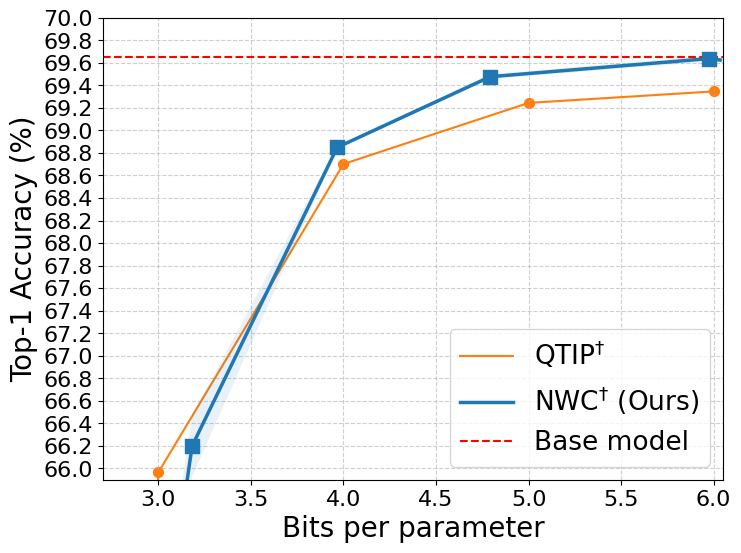

In [34]:
# ───────────────────────────────────────────────────────────────
# 설정 및 실행
# ───────────────────────────────────────────────────────────────

BASE_DIR_V2 = '/home/jgryu/workspace/weight_compression/hf_model_comp_results_v2'
BASE_DIR    = '/home/jgryu/workspace/weight_compression/hf_model_comp_results'

# ── SigLIP2 ──────────────────────────────────────────────────────
siglip_model_dir = f'{BASE_DIR_V2}/vision/google--siglip-base-patch16-224'

siglip_experiments = {
    # QTIP baseline (bit-based)
    'QTIP': {
        'data': collect_bit_experiment(
            f'{BASE_DIR}/qtip/google/siglip-base-patch16-224/{{b}}bit_imagenet_result.json',
            bits=[2, 3, 4, 5, 6],
            metric_scale=100.0,
        )
    },
    # NWC seed experiments (representative keys — averaged in seed_experiments)
    '(llama-siglib)_rnorm_ldlq128':       f'{siglip_model_dir}/(llama-siglib)_rnorm_ldlq128',
    '(llama)_rnorm_ldlq128':       f'{siglip_model_dir}/(llama)_rnorm_ldlq128',
    'rnorm_ldlq64_seed1':       f'{siglip_model_dir}/rnorm_ldlq64_seed1',
    'rnorm_ldlq64_seed2':       f'{siglip_model_dir}/rnorm_ldlq64_seed2',
    'rnorm_ldlq64_seed3':       f'{siglip_model_dir}/rnorm_ldlq64_seed3',
    'nsearch_ldlq64_seed1':       f'{siglip_model_dir}/nsearch_ldlq64_seed1',
    'nsearch_ldlq64_seed2':       f'{siglip_model_dir}/nsearch_ldlq64_seed2',
    'nsearch_ldlq64_seed3':       f'{siglip_model_dir}/nsearch_ldlq64_seed3',
    'rnorm_ldlq128_seed1':       f'{siglip_model_dir}/rnorm_ldlq128_seed1',
    'rnorm_ldlq128_seed2':       f'{siglip_model_dir}/rnorm_ldlq128_seed2',
    'rnorm_ldlq128_seed3':       f'{siglip_model_dir}/rnorm_ldlq128_seed3',
}

siglip_seed_experiments = {
    'NWC_norm_search_Avg': [
        'nsearch_ldlq64_seed1',
        'nsearch_ldlq64_seed2',
        'nsearch_ldlq64_seed3',
    ],
    'NWC_rnorm_Avg': [
        'rnorm_ldlq64_seed1',
        'rnorm_ldlq64_seed2',
        'rnorm_ldlq64_seed3',
    ],
    'NWC_rnorm128_Avg': [
        'rnorm_ldlq128_seed1',
        'rnorm_ldlq128_seed2',
        'rnorm_ldlq128_seed3',
    ],
    'NWC_Avg': [
        '(llama-siglib)_rnorm_ldlq128',
        '(llama)_rnorm_ldlq128',
        'rnorm_ldlq128_seed2',
    ],
}

siglip_exp_names   = [
    'QTIP',
    # '(llama-siglib)_rnorm_ldlq128',
    # '(llama)_rnorm_ldlq128',
    # 'NWC_rnorm_Avg',
    # 'NWC_norm_search_Avg',
    # 'NWC_rnorm128_Avg',
    # 'rnorm_ldlq128_seed1',
    # 'rnorm_ldlq128_seed2',
    # 'rnorm_ldlq128_seed3',
    'NWC_Avg',
    ]
siglip_plot_labels = siglip_exp_names
siglip_plot_labels = [r'QTIP$^†$', r'NWC$^†$ (Ours)']

plot_bpp_acc_vision(
    model_name='SigLIP',
    experiments=siglip_experiments,      # 시드 포함 전체 데이터 소스
    exp_names=siglip_exp_names,          # 플롯할 실험만
    plot_labels=siglip_plot_labels,
    seed_experiments=siglip_seed_experiments,
    model_dir=siglip_model_dir,
    metric_scale=100.0,
    metric_label='Top-1 Accuracy (%)',
    zoom_range=(2.7, 6.05),
    ylim=(65.9, 70),
    error_bar=True,
    error_style='region',
)


QTIP$^†$
|bpp    [2. 3. 4. 5. 6.]
|top1   [46.392 66.476 69.932 70.19  70.228]
|se     None
NWC$^†$ (Ours)
|bpp    [2.30193557 2.66561978 3.16220135 3.94638018 4.76867544 5.94376157]
|top1   [50.793      61.987      67.691      69.939      70.83066667 71.10266667]
|se     [0.541      0.033      0.109      0.075      0.07870056 0.00533333]
Plot saved to ./plots_figures/CLIP.pdf


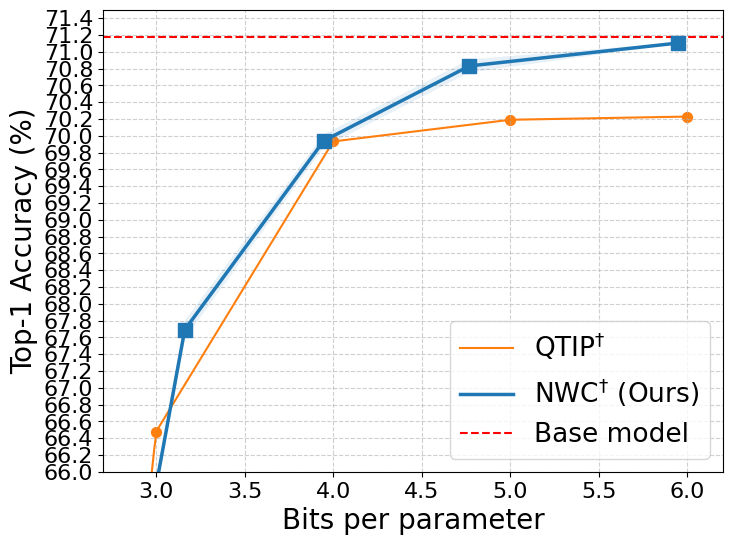

In [35]:
# ── CLIP ─────────────────────────────────────────────────────────

clip_model_dir = f'{BASE_DIR_V2}/vision/openai--clip-vit-large-patch14'

clip_experiments = {
    'QTIP': {
        'data': collect_bit_experiment(
            f'{BASE_DIR}/qtip/clip-vit-large-patch14/clip-vit-large-patch14_{{b}}bit_result.json',
            bits=[2, 3, 4, 5, 6],
            metric_scale=100.0,
        )
    },
    # '(clip)_rnorm_ldlq128':      f'{clip_model_dir}/(clip)_rnorm_ldlq128',
    # '(llama)_rnorm_ldlq128':     f'{clip_model_dir}/(llama)_rnorm_ldlq128',
    '(llama-clip)_rnorm_ldlq128':f'{clip_model_dir}/(llama-clip)_rnorm_ldlq128',
    'norm_search_ldlq64_seed1': f'{clip_model_dir}/norm_search_ldlq64_seed1',
    'norm_search_ldlq64_seed2': f'{clip_model_dir}/norm_search_ldlq64_seed2',
    'norm_search_ldlq64_seed3': f'{clip_model_dir}/norm_search_ldlq64_seed3',
    'rnorm_ldlq64_seed1': f'{clip_model_dir}/rnorm_ldlq64_seed1',
    'rnorm_ldlq64_seed2': f'{clip_model_dir}/rnorm_ldlq64_seed2',
    'rnorm_ldlq64_seed3': f'{clip_model_dir}/rnorm_ldlq64_seed3',
    # 'NWC_norm_search_Avg': 'dummy',  
}
clip_seed_experiments = {
    'NWC_norm_search_Avg': [
        'norm_search_ldlq64_seed1',
        'norm_search_ldlq64_seed2',
        'norm_search_ldlq64_seed3',
    ],
    'NWC_rnorm_Avg': [
        'rnorm_ldlq64_seed1',
        'rnorm_ldlq64_seed2',
        'rnorm_ldlq64_seed3',
    ],
}
clip_exp_names   = ['QTIP', '(llama-clip)_rnorm_ldlq128', 'NWC_norm_search_Avg', 'NWC_rnorm_Avg']
clip_plot_labels = [r'QTIP$^†$', r'NWC$^†$ (Ours)', 'NWC_norm_search_Avg', 'NWC_rnorm_Avg']

# clip_exp_names   = ['QTIP', '(llama-clip)_rnorm_ldlq128', 'NWC_norm_search_Avg', ]
# clip_plot_labels = [r'QTIP$^†$', 'NWC', 'NWC_norm_search_Avg',]

clip_exp_names   = ['QTIP', 'NWC_norm_search_Avg', ]
clip_plot_labels = [r'QTIP$^†$', r'NWC$^†$ (Ours)']

plot_bpp_acc_vision(
    model_name='CLIP',
    experiments=clip_experiments,      # 시드 포함 전체
    exp_names=clip_exp_names,          # 플롯할 것만
    plot_labels=clip_plot_labels,
    model_dir=clip_model_dir,
    metric_scale=100.0,
    seed_experiments=clip_seed_experiments,
    metric_label='Top-1 Accuracy (%)',
    zoom_range=(2.7, 6.2),
    ylim=(66, 71.5),
    error_bar=True,
)


In [36]:
f'{clip_model_dir}/norm_search_ldlq64_seed1'

'/home/jgryu/workspace/weight_compression/hf_model_comp_results_v2/vision/openai--clip-vit-large-patch14/norm_search_ldlq64_seed1'

QTIP$^†$
|bpp    [2. 3. 4. 5. 6.]
|top1   [83.894 85.726 86.008 86.072 86.078]
|se     None
NWC$^†$ (Ours)
|bpp    [2.3080422  2.66808991 3.16195823 3.94874438 4.77432401 5.95539462
 6.34562817]
|top1   [84.38466667 85.34733333 85.80733333 86.02266667 86.06666667 86.09
 86.075     ]
|se     [0.02649109 0.02384207 0.01576212 0.02880586 0.01271919 0.0072111
 0.003     ]
Plot saved to ./plots_figures/DINOv2.pdf


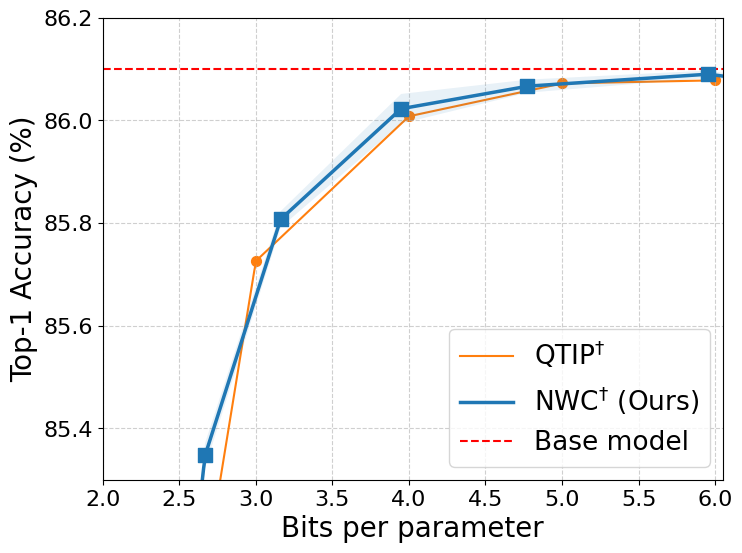

In [37]:
# ── DINOv2 ────────────────────────────────────────────────────────

dino_model_dir = f'{BASE_DIR_V2}/vision/facebook--dinov2-large-imagenet1k-1-layer'

dino_experiments = {
    'QTIP': {
        'data': collect_bit_experiment(
            f'{BASE_DIR}/qtip/facebook--dinov2-large-imagenet1k-1-layer/{{b}}bit_imagenet_result.json',
            bits=[2, 3, 4, 5, 6],
            metric_scale=1.0,   # DINOv2는 이미 % 단위
        )
    },
    '(llama-dino)ql_rnorm_ldlq128': f'{dino_model_dir}/(llama-dino)ql_rnorm_ldlq128',
    '(llama)ql_rnorm_ldlq128':      f'{dino_model_dir}/(llama)ql_rnorm_ldlq128',
    'rnorm_ldlq64_seed1':       f'{dino_model_dir}/rnorm_ldlq64_seed1',
    'rnorm_ldlq64_seed2':       f'{dino_model_dir}/rnorm_ldlq64_seed2',
    'rnorm_ldlq64_seed3':       f'{dino_model_dir}/rnorm_ldlq64_seed3',
    'nsearch_ldlq64_seed1':       f'{dino_model_dir}/nsearch_ldlq64_seed1',
    'nsearch_ldlq64_seed2':       f'{dino_model_dir}/nsearch_ldlq64_seed2',
    'nsearch_ldlq64_seed3':       f'{dino_model_dir}/nsearch_ldlq64_seed3',
    'rnorm_ldlq128_seed1':       f'{dino_model_dir}/rnorm_ldlq128_seed1',
    'rnorm_ldlq128_seed2':       f'{dino_model_dir}/rnorm_ldlq128_seed2',
    'rnorm_ldlq128_seed3':       f'{dino_model_dir}/rnorm_ldlq128_seed3',
}
dino_seed_experiments = {
    'NWC_norm_search_Avg': [
        'nsearch_ldlq64_seed1',
        'nsearch_ldlq64_seed2',
        'nsearch_ldlq64_seed3',
    ],
    'NWC_rnorm_Avg': [
        'rnorm_ldlq64_seed1',
        'rnorm_ldlq64_seed2',
        'rnorm_ldlq64_seed3',
    ],
    'NWC_Avg': [
        '(llama-dino)ql_rnorm_ldlq128',
        '(llama)ql_rnorm_ldlq128',
        # 'nsearch_ldlq64_seed2',
        'rnorm_ldlq128_seed3',
    ],
}

# dino_base = load_base_accuracy(
#     '/home/jgryu/workspace/weight_compression/hf_model_comp_results',
#     metric_scale=1.0,
# ) or 86.3  # fallback

dino_exp_names   = [
    'QTIP', 
    # '(llama-dino)ql_rnorm_ldlq128',
    # '(llama)ql_rnorm_ldlq128',
    # 'NWC_norm_search_Avg', 
    # 'NWC_rnorm_Avg'
    'NWC_Avg'
    # 'rnorm_ldlq128_seed1',
    # 'rnorm_ldlq128_seed2',
    # 'rnorm_ldlq128_seed3',
    # 'nsearch_ldlq64_seed1',
    # 'nsearch_ldlq64_seed2',
    # 'nsearch_ldlq64_seed3',
    ]
dino_plot_labels  = dino_exp_names
dino_plot_labels = [r'QTIP$^†$', r'NWC$^†$ (Ours)']

plot_bpp_acc_vision(
    model_name='DINOv2',
    experiments=dino_experiments,
    exp_names=dino_exp_names,
    plot_labels=dino_plot_labels,
    seed_experiments=dino_seed_experiments,
    base_accuracy=86.1,
    metric_scale=1.0,
    metric_label='Top-1 Accuracy (%)',
    zoom_range=(2.0, 6.05),
    ylim=(85.3, 86.2),
    error_bar=True,
)
